#  Khám phá và Tiền xử lý dữ liệu (ShanghaiTech Dataset)

**Nội dung thực hiện:**
1. Thiết lập môi trường và cấu hình đường dẫn.
2. Làm sạch dữ liệu.
3. Khám phá thống kê (EDA).
5. Tạo Density Map.
6. Trực quan hóa mẫu dữ liệu (Visualization).
7. Tăng cường dữ liệu (Augmentation).


## 1. Thiết lập môi trường và đường dẫn


In [14]:
import os
import glob
import h5py
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.io as sio
import PIL.Image as Image
import cv2
import yaml
from matplotlib import pyplot as plt
from matplotlib import cm as CM
from scipy.ndimage import gaussian_filter
from scipy.spatial import KDTree
from tqdm import tqdm
import random
import subprocess



PROJECT_ROOT  = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_ROOT     = os.path.join(PROJECT_ROOT, "data")
SHANGHAI_ROOT = os.path.join(DATA_ROOT, "ShanghaiTech")

PART_A_TRAIN  = os.path.join(SHANGHAI_ROOT, "part_A", "train_data")
PART_A_TEST   = os.path.join(SHANGHAI_ROOT, "part_A", "test_data")
PART_B_TRAIN  = os.path.join(SHANGHAI_ROOT, "part_B", "train_data")
PART_B_TEST   = os.path.join(SHANGHAI_ROOT, "part_B", "test_data")



## 2. Làm sạch dữ liệu

In [15]:
def clean_dataset(part="A"):
    paths = [PART_A_TRAIN, PART_A_TEST] if part == "A" else [PART_B_TRAIN, PART_B_TEST]
    print(f"\n--- Kiểm tra Part {part} ---")
    
    for p in paths:
        imgs = sorted(glob.glob(os.path.join(p, "images", "*.jpg")))
        errors = 0
        
        for img_p in imgs:
            mat_p = img_p.replace(".jpg", ".mat").replace("images", "ground-truth").replace("IMG_", "GT_IMG_")
            try:
                if not os.path.exists(mat_p): raise ValueError()
                with Image.open(img_p) as img: img.verify()
            except:
                errors += 1
                
        status = "Sạch" if errors == 0 else f"={errors} Lỗi"
        print(f" {os.path.basename(p):<10}: {len(imgs):>3} images | {status}")

clean_dataset("A")
clean_dataset("B")


--- Kiểm tra Part A ---
 train_data: 300 images | Sạch
 test_data : 182 images | Sạch

--- Kiểm tra Part B ---
 train_data: 400 images | Sạch
 test_data : 316 images | Sạch


## 3. Khám phá thống kê (EDA)


==================== Thống kê Part A - Train ====================


,Số người,Chiều rộng,Chiều cao
count,300.000000,300.000000,300.000000
mean,541.376667,872.193333,598.270000
std,505.162984,213.851375,165.865775
min,33.000000,299.000000,182.000000
25%,238.750000,689.500000,460.250000
50%,378.000000,1024.000000,652.500000
75%,652.500000,1024.000000,688.000000
max,3138.000000,1024.000000,1024.000000


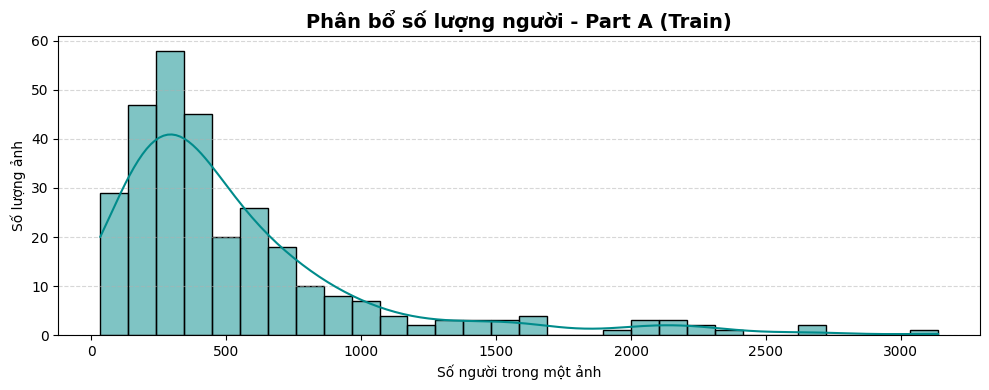


==================== Thống kê Part A - Test ====================


,Số người,Chiều rộng,Chiều cao
count,182.000000,182.000000,182.000000
mean,433.307692,861.912088,574.461538
std,354.438836,216.001389,169.311528
min,66.000000,293.000000,200.000000
25%,211.000000,650.500000,429.000000
50%,307.500000,1024.000000,611.000000
75%,500.750000,1024.000000,683.750000
max,2256.000000,1024.000000,1024.000000


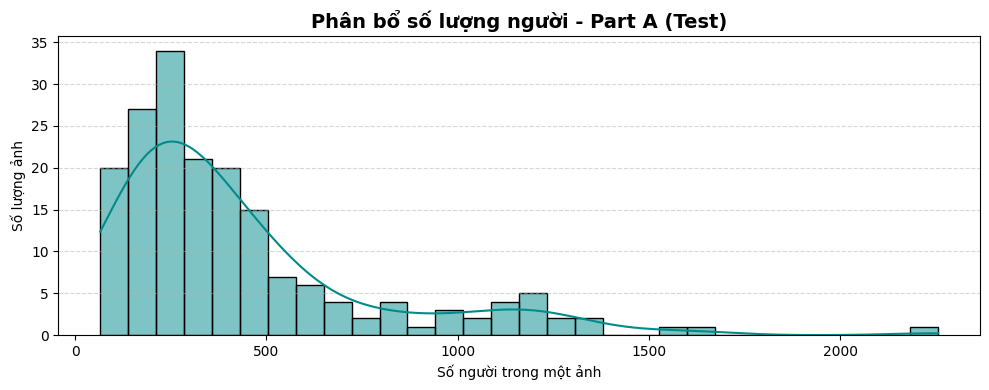


==================== Thống kê Part B - Train ====================


,Số người,Chiều rộng,Chiều cao
count,400.00000,400.0,400.0
mean,122.87750,1024.0,768.0
std,93.88647,0.0,0.0
min,12.00000,1024.0,768.0
25%,50.75000,1024.0,768.0
50%,99.00000,1024.0,768.0
75%,161.00000,1024.0,768.0
max,576.00000,1024.0,768.0


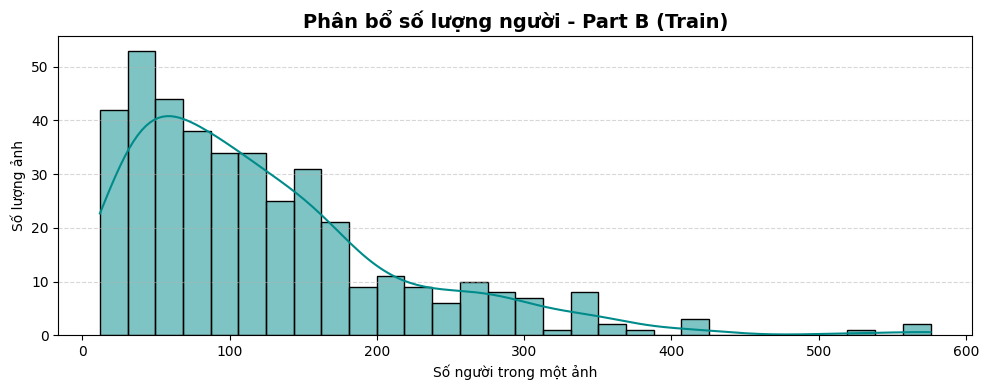


==================== Thống kê Part B - Test ====================


,Số người,Chiều rộng,Chiều cao
count,316.000000,316.0,316.0
mean,123.800633,1024.0,768.0
std,95.283144,0.0,0.0
min,9.000000,1024.0,768.0
25%,54.750000,1024.0,768.0
50%,93.000000,1024.0,768.0
75%,167.000000,1024.0,768.0
max,539.000000,1024.0,768.0


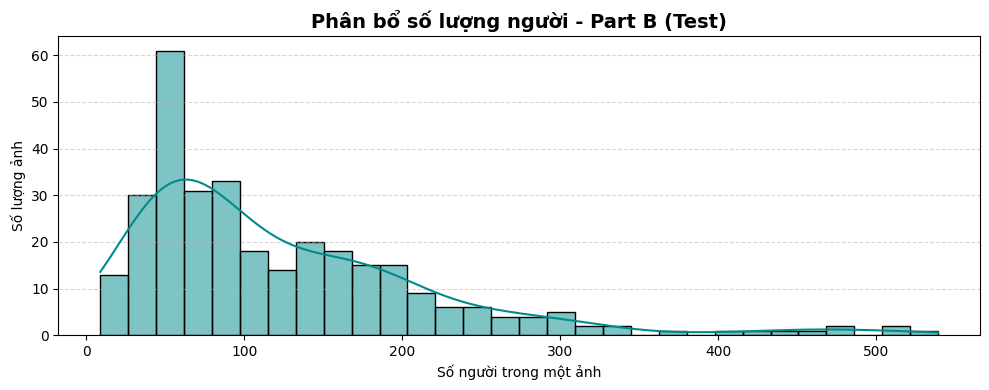

In [16]:
def get_stats(path):
    img_paths = glob.glob(os.path.join(path, "images", "*.jpg"))
    counts, dims = [], []
    
    for img_p in img_paths:
        mat_p = img_p.replace(".jpg", ".mat").replace("images", "ground-truth").replace("IMG_", "GT_IMG_")
        if os.path.exists(mat_p):
            mat = sio.loadmat(mat_p)
            # Lấy số lượng người từ file .mat
            counts.append(len(mat["image_info"][0, 0][0, 0][0]))
            with Image.open(img_p) as img:
                dims.append(img.size)
                
    return pd.DataFrame({
        "Số người": counts,
        "Chiều rộng": [d[0] for d in dims],
        "Chiều cao": [d[1] for d in dims]
    })

# Danh sách các tập dữ liệu cần khám phá
dataset_splits = [
    ("Part A", "Train", PART_A_TRAIN),
    ("Part A", "Test", PART_A_TEST),
    ("Part B", "Train", PART_B_TRAIN),
    ("Part B", "Test", PART_B_TEST)
]

for part, split, path in dataset_splits:
    try:
        df = get_stats(path)
        print(f"\n{'='*20} Thống kê {part} - {split} {'='*20}")
        display(df.describe()) # Hiển thị bảng thống kê chuẩn trong Notebook
        
        # Vẽ biểu đồ phân bổ
        plt.figure(figsize=(10, 4))
        sns.histplot(df["Số người"], kde=True, color='darkcyan', bins=30)
        plt.title(f"Phân bổ số lượng người - {part} ({split})", fontsize=14, fontweight='bold')
        plt.xlabel("Số người trong một ảnh")
        plt.ylabel("Số lượng ảnh")
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Lỗi khi xử lý {part} {split}: {e}")

## 4. Tạo Density Map

In [17]:
def generate_density_map(img_shape, points, adaptive_kernel=True, k=3, beta=0.3, fixed_sigma=15):
    height, width = img_shape
    density = np.zeros((height, width), dtype=np.float32)
    if len(points) == 0: return density
    
    if adaptive_kernel and len(points) > k:

        tree = KDTree(points, leafsize=2048)
        distances, _ = tree.query(points, k=k+1)
        sigmas = np.mean(distances[:, 1:], axis=1) * beta
        sigmas = np.clip(sigmas, 1, 50)
    else:
        sigmas = np.full(len(points), fixed_sigma, dtype=np.float32)
        
    for i, (x, y) in enumerate(points):
        ix, iy = int(round(x)), int(round(y))
        if iy >= height or ix >= width or iy < 0 or ix < 0: continue
            
        sigma = sigmas[i]
        radius = int(sigma * 3)
        
        y_min = max(0, iy - radius)
        y_max = min(height, iy + radius + 1)
        x_min = max(0, ix - radius)
        x_max = min(width, ix + radius + 1)
        
        local_h, local_w = y_max - y_min, x_max - x_min
        local_pt2d = np.zeros((local_h, local_w), dtype=np.float32)
        local_pt2d[iy - y_min, ix - x_min] = 1.0
        
       
        blurred = gaussian_filter(local_pt2d, sigma, mode='constant')
        

        total_density = blurred.sum()
        if total_density > 0:
            blurred = blurred / total_density
        
        density[y_min:y_max, x_min:x_max] += blurred
        
    return density

def process_dataset(path, part='A', force_regenerate=True):
    img_paths = sorted(glob.glob(os.path.join(path, "images", "*.jpg")))
    print(f"\n--- Generating Density Maps for Part {part} ({len(img_paths)} images) ---")
    
    # Khởi tạo các biến để tính tổng sai số
    total_error = 0
    
    for p in tqdm(img_paths):
        mat_p = p.replace(".jpg", ".mat").replace("images", "ground-truth").replace("IMG_", "GT_IMG_")
        h5_p  = p.replace(".jpg", ".h5").replace("images", "ground-truth")
        
        # Bỏ qua nếu option force_regenerate là Ghi đè (True) 
        if os.path.exists(h5_p) and not force_regenerate: 
            continue
            
        img = Image.open(p)
        mat = sio.loadmat(mat_p)
        gt = mat["image_info"][0, 0][0, 0][0]
        
  
        dm = generate_density_map((img.size[1], img.size[0]), gt, adaptive_kernel=(part == 'A'))
        
      
        gt_count = len(gt)              
        dm_sum = np.sum(dm)             
        error = abs(gt_count - dm_sum)
        total_error += error
      
        if error > 0.5:
            print(f"ẢNH BÁO tại file {os.path.basename(p)}: Ground Truth = {gt_count}, Trong khi tính ra np.sum = {dm_sum:.4f} (Sai lệch: {error:.4f})")
        # ---------------------------------------------
        
        with h5py.File(h5_p, 'w') as f:
            f.create_dataset('density', data=dm)

    mean_error = total_error / len(img_paths)
    print(f"Hoàn tất tập Part {part}. MAE Sai số Tổng/Điểm Ground-truth: {mean_error:.5f}")

process_dataset(PART_A_TRAIN, part='A', force_regenerate=True)
process_dataset(PART_A_TEST, part='A', force_regenerate=True)
process_dataset(PART_B_TRAIN, part='B', force_regenerate=True)
process_dataset(PART_B_TEST, part='B', force_regenerate=True)


--- Generating Density Maps for Part A (300 images) ---


 20%|██        | 60/300 [00:14<00:53,  4.48it/s]

ẢNH BÁO tại file IMG_151.jpg: Ground Truth = 987, Trong khi tính ra np.sum = 984.9999 (Sai lệch: 2.0001)


 25%|██▍       | 74/300 [00:17<00:41,  5.45it/s]

ẢNH BÁO tại file IMG_165.jpg: Ground Truth = 468, Trong khi tính ra np.sum = 467.0000 (Sai lệch: 1.0000)


...

ẢNH BÁO tại file IMG_232.jpg: Ground Truth = 133, Trong khi tính ra np.sum = 132.0000 (Sai lệch: 1.0000)


 97%|█████████▋| 306/316 [00:56<00:01,  8.68it/s]

ẢNH BÁO tại file IMG_88.jpg: Ground Truth = 163, Trong khi tính ra np.sum = 162.0000 (Sai lệch: 1.0000)


100%|██████████| 316/316 [00:58<00:00,  5.37it/s]

Hoàn tất tập Part B. MAE Sai số Tổng/Điểm Ground-truth: 0.03483


## 5. Trực quan hóa mẫu dữ liệu (Visualization)


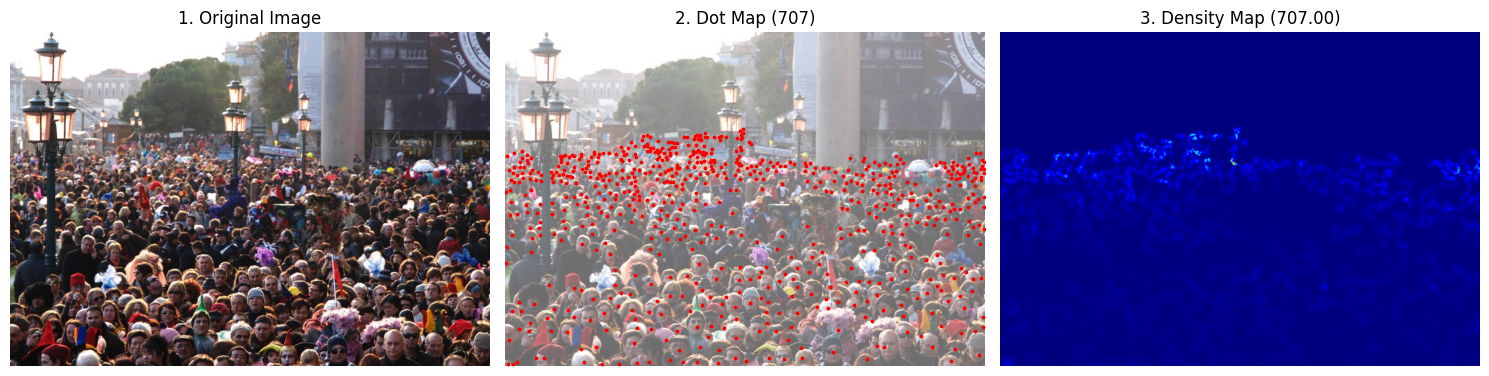

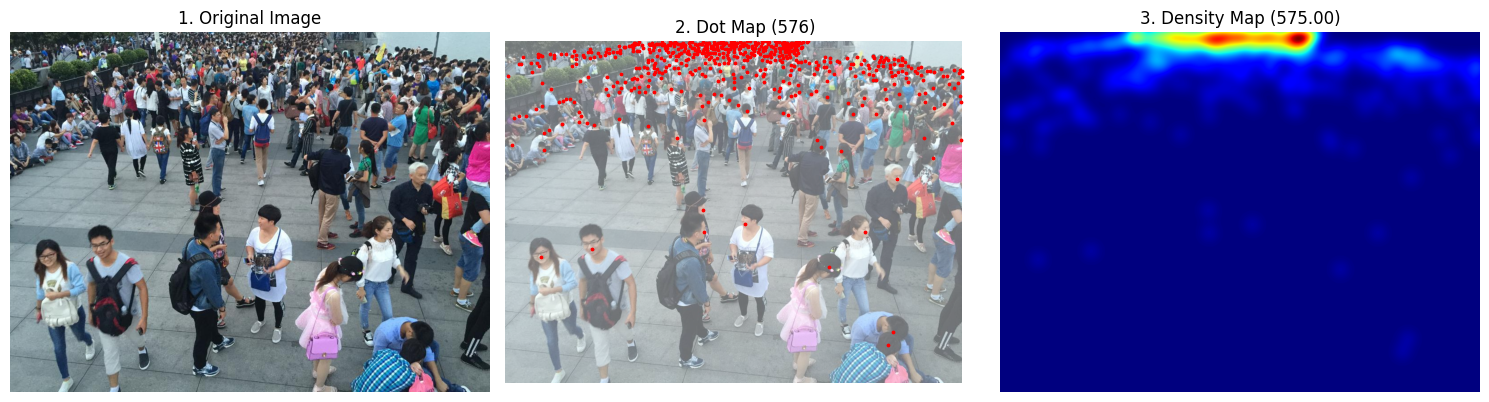

In [18]:
def check_h5_sample(img_no, part="A", subset="train_data"):
    base_path = os.path.join(SHANGHAI_ROOT, f"part_{part}", subset)
    img_p = os.path.join(base_path, "images", f"IMG_{img_no}.jpg")
    mat_p = os.path.join(base_path, "ground-truth", f"GT_IMG_{img_no}.mat")
    h5_p  = os.path.join(base_path, "ground-truth", f"IMG_{img_no}.h5")

    if not all(os.path.exists(f) for f in [img_p, mat_p, h5_p]):
        print(f"Thiếu dữ liệu cho IMG_{img_no}")
        return

    # Load dữ liệu
    img = Image.open(img_p)
    gt  = sio.loadmat(mat_p)["image_info"][0, 0][0, 0][0]
    with h5py.File(h5_p, "r") as hf: dm = np.asarray(hf["density"])

    # Hiển thị
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    titles = ["1. Original Image", f"2. Dot Map ({len(gt)})", f"3. Density Map ({dm.sum():.2f})"]
    
    axes[0].imshow(img)
    # Chồng dots lên ảnh gốc để dễ quan sát hơn
    axes[1].imshow(img, alpha=0.6)
    axes[1].scatter(gt[:, 0], gt[:, 1], s=3, c="red")
    axes[2].imshow(dm, cmap=CM.jet)

    for i, ax in enumerate(axes):
        ax.set_title(titles[i])
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

# Kiểm tra thử mẫu
check_h5_sample(2, part="A")
check_h5_sample(222, part="B")

## 6. Tăng cường dữ liệu


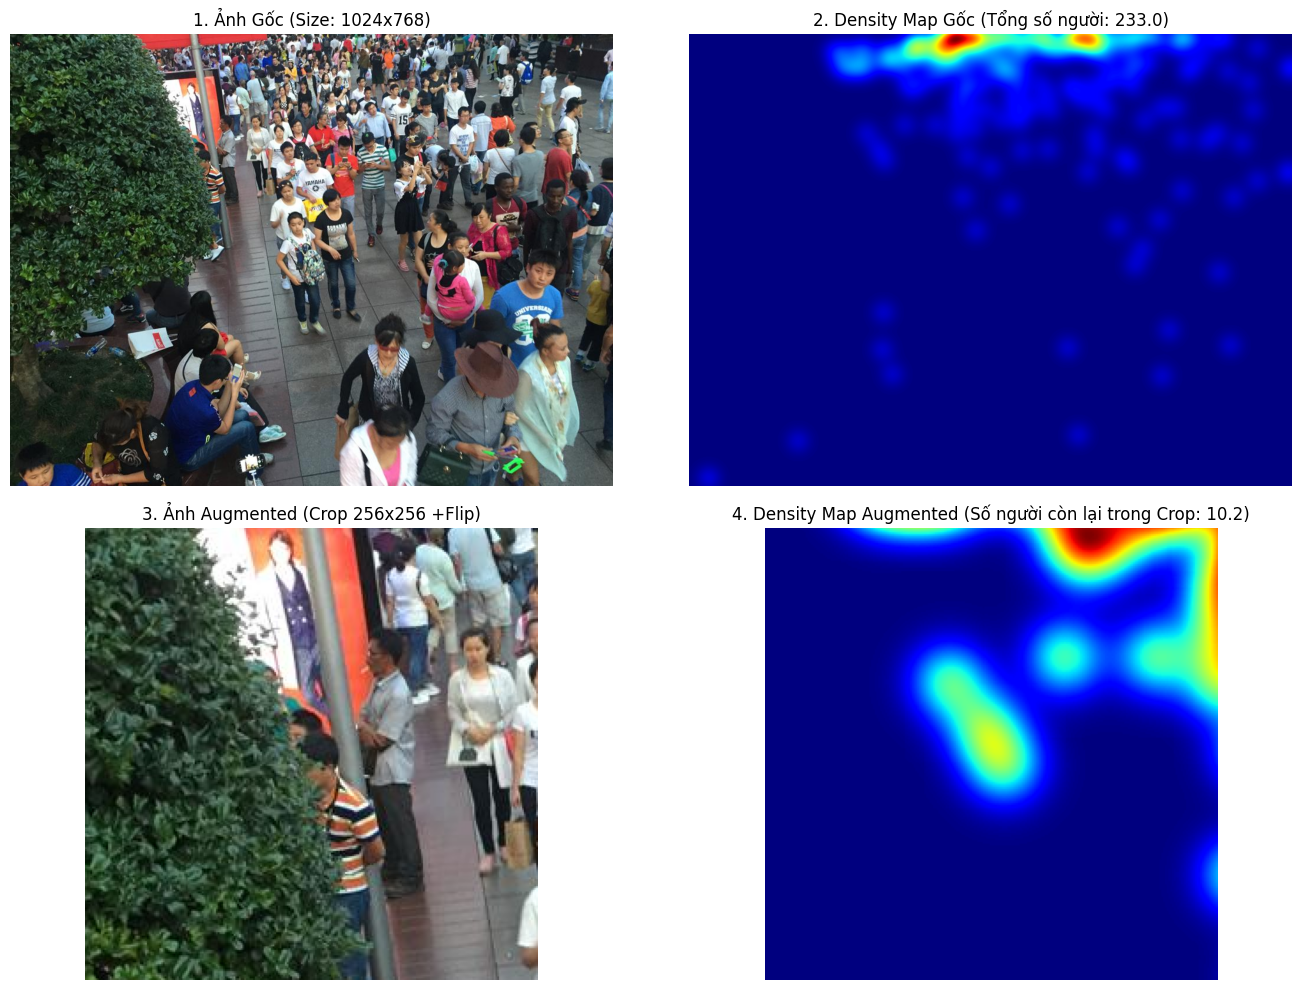

In [19]:
def augment_sample_advanced(img_no, part="A", crop_size=(256, 256)):
    train_path = os.path.join(SHANGHAI_ROOT, f"part_{part}", "train_data")
    img_p = os.path.join(train_path, "images", f"IMG_{img_no}.jpg")
    h5_p  = os.path.join(train_path, "ground-truth", f"IMG_{img_no}.h5")

    if not os.path.exists(img_p) or not os.path.exists(h5_p):
        print(f"Không tìm thấy file cho IMG_{img_no} Part {part}")
        return


    img = Image.open(img_p).convert('RGB')
    with h5py.File(h5_p, "r") as hf:
        dm = np.asarray(hf["density"])

    W, H = img.size
    cw, ch = crop_size
    
    x1 = random.randint(0, max(0, W - cw) if W > cw else 0)
    y1 = random.randint(0, max(0, H - ch) if H > ch else 0)
    
    img_aug = img.crop((x1, y1, x1 + cw, y1 + ch))
    dm_aug = dm[y1:y1 + ch, x1:x1 + cw]
    
    # Bước 2: Random Horizontal Flip (Áp dụng cho CẢ img và dm với xác suất 50%)
    if random.random() > 0.5:
        img_aug = img_aug.transpose(Image.FLIP_LEFT_RIGHT)
        dm_aug = np.fliplr(dm_aug) 
        

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
 
    axes[0, 0].imshow(img)
    axes[0, 0].set_title(f"1. Ảnh Gốc (Size: {W}x{H})")
    
    axes[0, 1].imshow(dm, cmap='jet')
    axes[0, 1].set_title(f"2. Density Map Gốc (Tổng số người: {np.sum(dm):.1f})")
    
    axes[1, 0].imshow(img_aug)
    axes[1, 0].set_title(f"3. Ảnh Augmented (Crop {cw}x{ch} +Flip)")
    
    axes[1, 1].imshow(dm_aug, cmap='jet')
    axes[1, 1].set_title(f"4. Density Map Augmented (Số người còn lại trong Crop: {np.sum(dm_aug):.1f})")
    
    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()


augment_sample_advanced(1, part="B")

In [20]:
def augment_data(img_path, h5_path, save_dir, num_crops=4, crop_size=256):
    """
    Thực hiện Random Crop và Horizontal Flip cho cả ảnh và bản đồ mật độ.
    """
    # Đọc ảnh và bản đồ mật độ
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    with h5py.File(h5_path, 'r') as hf:
        density = np.asarray(hf.get('density'))
        
    h, w = img.shape[:2]
    base_name = os.path.basename(img_path).replace('.jpg', '')
    
    # Tạo thư mục lưu nếu chưa có
    aug_img_dir = os.path.join(save_dir, 'images')
    aug_h5_dir = os.path.join(save_dir, 'ground-truth')
    os.makedirs(aug_img_dir, exist_ok=True)
    os.makedirs(aug_h5_dir, exist_ok=True)

    for i in range(num_crops):
        # 1. Random Crop
        if h > crop_size and w > crop_size:
            dx = random.randint(0, w - crop_size)
            dy = random.randint(0, h - crop_size)
        else:
            dx, dy = 0, 0
            # Nếu ảnh nhỏ hơn crop_size thì resize hoặc skip (ở đây skip để giữ chất lượng)
            continue
            
        img_crop = img[dy:dy+crop_size, dx:dx+crop_size]
        den_crop = density[dy:dy+crop_size, dx:dx+crop_size]
        
        # 2. Horizontal Flip (xác suất 50%)
        if random.random() > 0.5:
            img_crop = cv2.flip(img_crop, 1)
            den_crop = cv2.flip(den_crop, 1)
            
        # Lưu ảnh augmented
        save_name = f"{base_name}_aug_{i}.jpg"
        Image.fromarray(img_crop).save(os.path.join(aug_img_dir, save_name))
        
        # Lưu mật độ augmented
        with h5py.File(os.path.join(aug_h5_dir, save_name.replace('.jpg', '.h5')), 'w') as hf:
            hf.create_dataset('density', data=den_crop)

# Ví dụ chạy thử augmentation cho Part A Train
# Lưu ý: Việc này sẽ tạo ra 300 * 4 = 1200 ảnh huấn luyện mới
AUG_PART_A_TRAIN = os.path.join(SHANGHAI_ROOT, "part_A", "augmented_train")

print("Đang thực hiện Augmentation cho Part A...")
train_imgs = glob.glob(os.path.join(PART_A_TRAIN, "images", "*.jpg"))

for img_p in tqdm(train_imgs):
    h5_p = img_p.replace("images", "ground-truth").replace(".jpg", ".h5")
    augment_data(img_p, h5_p, AUG_PART_A_TRAIN, num_crops=4, crop_size=256)

print(f"Hoàn tất! Dữ liệu tăng cường được lưu tại: {AUG_PART_A_TRAIN}")

Đang thực hiện Augmentation cho Part A...


100%|██████████| 300/300 [00:06<00:00, 47.13it/s]

Hoàn tất! Dữ liệu tăng cường được lưu tại: /data/ShanghaiTech/part_A/augmented_train
